In [1]:
# MFIT 860: Acquisition and Management of Data 
# Professor: Alex Scott 
# Date: July 7th, 2026 
# Team Simcoe: Alina Usova, Rish Sheth, Sally Shan, Njavwa Chailunga, Abdoulaye Bah 

In [2]:
# Importing all needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from os.path import curdir
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols

In [3]:
# Question 1a

xl_path = os.path.join(curdir, 'Data', '860_Assignment1_Data_vf.xlsx')

# Loading the specific sheet, skipping the first 16 rows
island_airport_weather = pd.read_excel(
    xl_path, 
    sheet_name='Island Airport Weather', 
    header=16  # Row 17 is index 16
)

# Preview the data
#island_airport_weather.head()

# Validate Type
#island_airport_weather.dtypes

In [4]:
# Question 1a continued

# Calculate air density using the provided formula
# Formula: (Stn Press * 1000) / (287.05 * (Temp + 273.15))
island_airport_weather['Air_Density'] = (island_airport_weather['Stn Press (kPa)'] * 1000) / (287.05 * (island_airport_weather['Temp (°C)'] + 273.15))

# Print out the first 5 records to show your answer snippet
island_airport_weather[['Stn Press (kPa)', 'Temp (°C)', 'Air_Density']].head()

,Stn Press (kPa),Temp (°C),Air_Density
0,98.49,4.3,1.236659
1,98.47,5.1,1.232853
2,98.57,5.9,1.230567
3,98.98,3.3,1.247307
4,99.29,2.8,1.253480


In [5]:
# Question 1b

# Convert wind speed from km/h to m/s
island_airport_weather['Wind_Spd_ms'] = island_airport_weather['Wind Spd (km/h)'] * 0.277778

# Print out the first 5 records to show your answer snippet
island_airport_weather[['Wind Spd (km/h)', 'Wind_Spd_ms']].head()

,Wind Spd (km/h),Wind_Spd_ms
0,11,3.055558
1,4,1.111112
2,28,7.777784
3,34,9.444452
4,28,7.777784


In [6]:
# Question 1c

# Loading the specific sheet
turbine_specs = pd.read_excel(
    xl_path, 
    sheet_name='Turbine Specifications'
)

# Preview the data
turbine_specs.head()

# Validate Type
#turbine_specs.dtypes

,Field,Comments,Values,Units
0,Wind facility name/ID,The name of the wind facility,Toronto Wind One,NaN
1,Number of turbines,Number of turbines at this facility,49,NaN
2,Cut-in windspeed (m/s),The minimum wind speed needed for the turbine ...,4,m/s
3,Cut-out windspeed (m/s),The maximum wind speed at which the turbine wi...,32,m/s
4,Maximum power coefficient,"Generally accepted to be from 0.25 to 0.45, us...",0.35,NaN


In [7]:
# Question 1c continued

# 1. Extract and convert values from turbine_specs
cut_in = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Cut-in windspeed (m/s)', 'Values'].values[0])
cut_out = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Cut-out windspeed (m/s)', 'Values'].values[0])
max_cp = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Maximum power coefficient', 'Values'].values[0])
swept_area = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Turbine swept area', 'Values'].values[0])
nominal_power_mw = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Turbine nominal power', 'Values'].values[0])
nominal_power_watts = nominal_power_mw * 1000000

# print(cut_in)
# print(cut_out)
# print(max_cp)
# print(swept_area)
# print(nominal_power_mw)
# print(nominal_power_watts)

# 2. Calculate the baseline power using the formula
# power = Air_Density * Swept_Area * 0.5 * (Wind_Spd_ms^3) * Max_Cp
island_airport_weather['Power_Watts'] = island_airport_weather['Air_Density'] * swept_area * 0.5 * (island_airport_weather['Wind_Spd_ms'] ** 3) * max_cp

# 3. Apply the constraints using np.where
# Condition 1: If wind is below cut-in OR above cut-out, power is 0
island_airport_weather['Power_Watts'] = np.where(
    (island_airport_weather['Wind_Spd_ms'] < cut_in) | (island_airport_weather['Wind_Spd_ms'] > cut_out), 
    0, 
    island_airport_weather['Power_Watts']
)

# Condition 2: Cap the power at the turbine's nominal maximum capacity
island_airport_weather['Power_Watts'] = np.where(
    island_airport_weather['Power_Watts'] > nominal_power_watts, 
    nominal_power_watts, 
    island_airport_weather['Power_Watts']
)

# Print out the first 5 records
island_airport_weather[['Wind_Spd_ms', 'Air_Density', 'Power_Watts']].head()

,Wind_Spd_ms,Air_Density,Power_Watts
0,3.055558,1.236659,0.000000e+00
1,1.111112,1.232853,0.000000e+00
2,7.777784,1.230567,1.344892e+06
3,9.444452,1.247307,2.440722e+06
4,7.777784,1.253480,1.369935e+06


In [8]:
# Question 1d

# 1. Sum up the hourly power produced by a single turbine
total_power_single_turbine_watts = island_airport_weather['Power_Watts'].sum()

# 2. Multiply by the 49 turbines in the windfarm
total_windfarm_power_watts = total_power_single_turbine_watts * 49

# 3. Convert the total power from Watts to Megawatts (divide by 1,000,000)
total_windfarm_power_mw = total_windfarm_power_watts / 1000000

# Print the final result
print(f"Total Electricity Produced for the Windfarm in January: {total_windfarm_power_mw:.2f} MW")

Total Electricity Produced for the Windfarm in January: 43077.82 MW


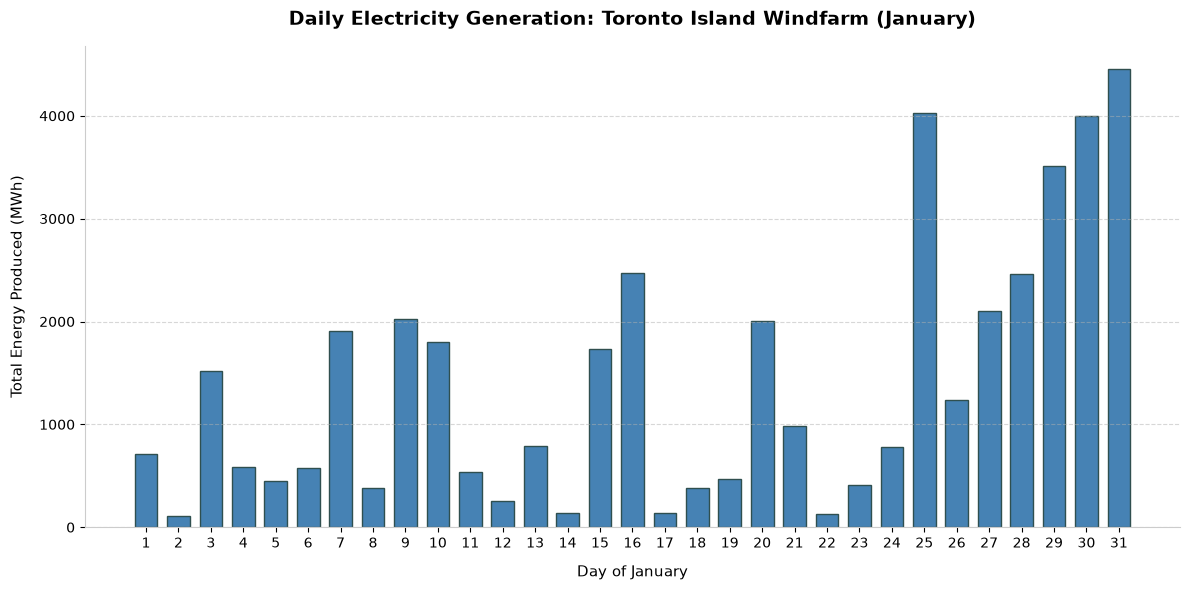

In [9]:
# Question 1e

# 1. Calculate daily windfarm energy production
# Group by the existing 'Day' column, sum the hourly Power_Watts, 
# multiply by 49 turbines, and divide by 1,000,000 to convert to MWh
daily_energy = (island_airport_weather.groupby('Day')['Power_Watts'].sum() * 49) / 1000000

# 2. Create the professional bar chart
# Using subplots to avoid plt.figure() as per best practices
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars in chronological order (Day 1 to 31) with a professional steel blue color
ax.bar(daily_energy.index, daily_energy.values, color='#4682B4', edgecolor='#2F4F4F', width=0.7)

# Title and Labels
ax.set_title('Daily Electricity Generation: Toronto Island Windfarm (January)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Day of January', fontsize=11, labelpad=10)
ax.set_ylabel('Total Energy Produced (MWh)', fontsize=11, labelpad=10)

# Clean up chart borders (Spines) to reduce visual clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle horizontal gridlines for easier value reading
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ensure the x-axis displays every single day from 1 to 31 clearly without overlapping
ax.set_xticks(daily_energy.index)

# Adjust layout and save the image file
plt.tight_layout()
plt.show()

In [10]:
# Question 3

# Libraries needed for question 3

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# from os.path import curdir
# import seaborn as sns

In [11]:
# 3a

# Loading data into df

xl_path = os.path.join(curdir, 'Data', '860_Assignment1_Data_vf.xlsx')

sales = pd.read_excel(
    xl_path, 
    sheet_name='Product_Sales',
    index_col='Obs'
)

# See what data looks like
sales.head()

,Product_ID,Sales_2016,Sales_2017,Import,Num_Retailers,Price
Obs,,,,,,
1,1,1162.91,235.19,1,5,$67.18
2,2,1191.11,944.87,1,3,$54.56
3,3,1214.96,737.06,0,5,$58.85
4,4,1336.07,986.15,0,7,$56.48
5,5,1343.29,871.33,1,7,$58.74


In [12]:
# Evaluating data types
sales.dtypes

Product_ID         int64
Sales_2016       float64
Sales_2017       float64
Import             int64
Num_Retailers      int64
Price                str
dtype: object

In [13]:
# What is the largest product ID because that will define how many 0's we need to add ahead of the other values
sales["Product_ID"].max()

np.int64(200)

In [14]:
# Convert product id to string and add zeros to length of 3
sales['Product_ID'] = sales['Product_ID'].astype(str).str.zfill(3)

# Verify results
print(sales['Product_ID'].dtypes)
print(sales[['Product_ID']].head())

str
    Product_ID
Obs           
1          001
2          002
3          003
4          004
5          005


In [15]:
# 3b

# Evaluating data types
sales.dtypes

Product_ID           str
Sales_2016       float64
Sales_2017       float64
Import             int64
Num_Retailers      int64
Price                str
dtype: object

In [16]:
# Evaluating what data looks like
sales.head()

,Product_ID,Sales_2016,Sales_2017,Import,Num_Retailers,Price
Obs,,,,,,
1,001,1162.91,235.19,1,5,$67.18
2,002,1191.11,944.87,1,3,$54.56
3,003,1214.96,737.06,0,5,$58.85
4,004,1336.07,986.15,0,7,$56.48
5,005,1343.29,871.33,1,7,$58.74


In [17]:
# Each sales observation for 2016 and 2017 has its own column instead of individual row
# Price is an object and needs to be converted to float

# 1. Melt the dataframe to fix the wide structure
sales_tidy = sales.melt(
    id_vars=['Product_ID', 'Import', 'Num_Retailers', 'Price'], 
    value_vars=['Sales_2016', 'Sales_2017'], # Columns that need to be consolidated
    var_name='Year', # New Column that will hold previous column name case dependent
    value_name='Sales' # New column that will hold the previous column value case dependent
)

# Clean up the 'Year' column so it just shows the actual year (e.g., '2016' instead of 'Sales_2016')
sales_tidy['Year'] = sales_tidy['Year'].str.replace('Sales_', '')

# 2. Clean the Price column (remove '$' and convert to float). Note regex here tells python to not use regular expressions which would lead to the last character being deleted instead of the literal $ sign
sales_tidy['Price'] = sales_tidy['Price'].str.replace('$', '', regex=False).astype(float)

# Verify the changes
print(sales_tidy.dtypes)
print(sales_tidy.head())

Product_ID           str
Import             int64
Num_Retailers      int64
Price            float64
Year                 str
Sales            float64
dtype: object
  Product_ID  Import  Num_Retailers  Price  Year    Sales
0        001       1              5  67.18  2016  1162.91
1        002       1              3  54.56  2016  1191.11
2        003       0              5  58.85  2016  1214.96
3        004       0              7  56.48  2016  1336.07
4        005       1              7  58.74  2016  1343.29


In [18]:
# Year should be numeric so we can sort by it and use for calculation if needed

sales_tidy['Year'] = sales_tidy['Year'].astype(int)

sales_tidy.dtypes

Product_ID           str
Import             int64
Num_Retailers      int64
Price            float64
Year               int64
Sales            float64
dtype: object

In [19]:
# As additional best practice, even though does not seem to be the case we will drop dupes

# Checking the number of rows before
print("Rows before dropping absolute duplicates:", sales_tidy.shape[0])

# Drop rows where entire row is a duplicate, keeping the first occurrence
sales_tidy = sales_tidy.drop_duplicates()

# Checking the number of rows after
print("Rows after dropping absolute duplicates:", sales_tidy.shape[0])

Rows before dropping absolute duplicates: 400
Rows after dropping absolute duplicates: 400


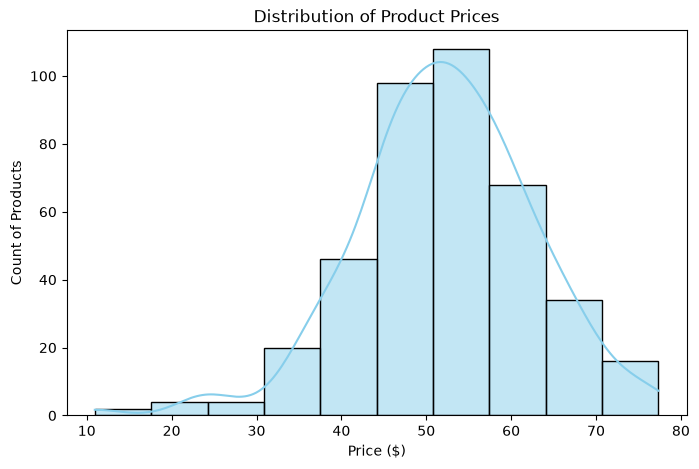

In [20]:
# 3c

# Histogram is a good way to visualize distribution of prices
# Using seaborn to be able to show smooth trend line and modern look
# We will split prices into 10 bins
# Given there should be 2 records for each price due to tidying activity, we will display 2 variants of graph:
#   1) Price Distribution across the data from 2 years
#   2) Price Distribution of unique price for each product (Essentially rewinding the melt)
# The net effect of number 2 above would really be halving the length of the histogram

# import matplotlib.pyplot as plt
# import seaborn as sns

#3c-1

plt.figure(figsize=(8, 5))
sns.histplot(data=sales_tidy, x='Price', bins=10, kde=True, color='skyblue')
plt.title('Distribution of Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count of Products')
plt.show()

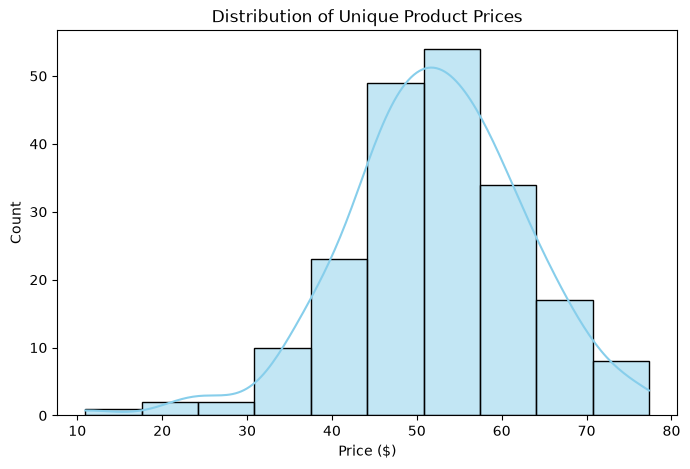

In [21]:
#3c-2
plt.figure(figsize=(8, 5))

# Filter duplicates only if BOTH Product_ID and Price are identical
unique_price_records = sales_tidy.drop_duplicates(subset=['Product_ID', 'Price'])

# Plot using the safe filtered data
sns.histplot(
    data=unique_price_records, 
    x='Price', 
    bins=10, 
    kde=True, 
    color='skyblue', 
    edgecolor='black'
)

plt.title('Distribution of Unique Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

Correlation Matrix:
 [[ 1.         -0.05023465]
 [-0.05023465  1.        ]]

The correlation between Price and Number of Retailers is: -0.0502


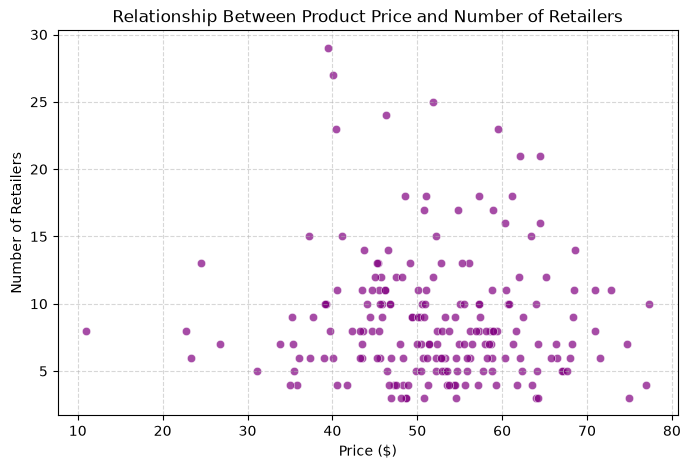

In [22]:
# 3d

# 1. Calculate the correlation coefficient matrix using numpy
# Using safe unique_price_records so we don't skew the relationship with duplicate rows
correlation_matrix = np.corrcoef(unique_price_records['Price'], unique_price_records['Num_Retailers'])
print("Correlation Matrix:\n", correlation_matrix)

# 2. Identifying the correlation value between Price and Num_Retailers
# (It's at row 0, column 1 in the matrix)
correlation_value = correlation_matrix[0, 1]
print(f"\nThe correlation between Price and Number of Retailers is: {correlation_value:.4f}")

# 3. Creating the scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=unique_price_records, 
    x='Price', 
    y='Num_Retailers', 
    color='purple', 
    alpha=0.7
)

plt.title('Relationship Between Product Price and Number of Retailers')
plt.xlabel('Price ($)')
plt.ylabel('Number of Retailers')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [23]:
#3d Conclusion
print(f"The correlation between Price and Number of Retailers is: {correlation_value:.4f}.\nA correlation close to zero means there is no meaningful relationship between how much a product costs and how many retailers choose to sell it.\nFor a business owner, this tells us that pricing decisions and retailer adoption are completely independent.\nPricing a product higher or lower won't predictably change how many stores carry it.")

The correlation between Price and Number of Retailers is: -0.0502.
A correlation close to zero means there is no meaningful relationship between how much a product costs and how many retailers choose to sell it.
For a business owner, this tells us that pricing decisions and retailer adoption are completely independent.
Pricing a product higher or lower won't predictably change how many stores carry it.


In [24]:
# 3e

# Ideated through countless charts using various combination of data. It seems that the most practical one is to see top 10 winners and loosers going from 2016 to 2017

# Creating 2 new df one for each year
df_2016 = sales_tidy[sales_tidy["Year"] == 2016].set_index("Product_ID")
df_2017 = sales_tidy[sales_tidy["Year"] == 2017].set_index("Product_ID")

# Creating combined df showing year-over-year growth
df_yoy = df_2017.copy()
df_yoy["Sales_2016"] = df_2016["Sales"]
df_yoy["Sales_Growth"] = df_yoy["Sales"] - df_yoy["Sales_2016"]

df_yoy.head()

,Import,Num_Retailers,Price,Year,Sales,Sales_2016,Sales_Growth
Product_ID,,,,,,,
001,1,5,67.18,2017,235.19,1162.91,-927.72
002,1,3,54.56,2017,944.87,1191.11,-246.24
003,0,5,58.85,2017,737.06,1214.96,-477.90
004,0,7,56.48,2017,986.15,1336.07,-349.92
005,1,7,58.74,2017,871.33,1343.29,-471.96


In [25]:
# New df with top and bottom 10 sales change records
sorted_growth = df_yoy.sort_values(by="Sales_Growth")
extremes = pd.concat([sorted_growth.head(10), sorted_growth.tail(10)])
extremes = extremes.reset_index()
extremes = extremes.sort_values("Sales_Growth", ascending=False)

extremes

,Product_ID,Import,Num_Retailers,Price,Year,Sales,Sales_2016,Sales_Growth
19,085,0,8,10.95,2017,3955.69,1846.99,2108.70
18,145,0,8,22.78,2017,3192.44,1722.56,1469.88
17,156,1,6,23.33,2017,3094.79,1654.61,1440.18
16,017,0,13,24.58,2017,3359.82,1987.14,1372.68
15,038,0,7,26.81,2017,2919.56,1667.30,1252.26
14,033,0,5,31.08,2017,2532.34,1510.66,1021.68
13,019,0,7,33.83,2017,2444.15,1570.97,873.18
12,182,0,4,35.06,2017,2223.97,1417.21,806.76
11,127,0,9,35.25,2017,2451.81,1655.31,796.50
10,049,0,7,35.37,2017,2355.10,1565.08,790.02


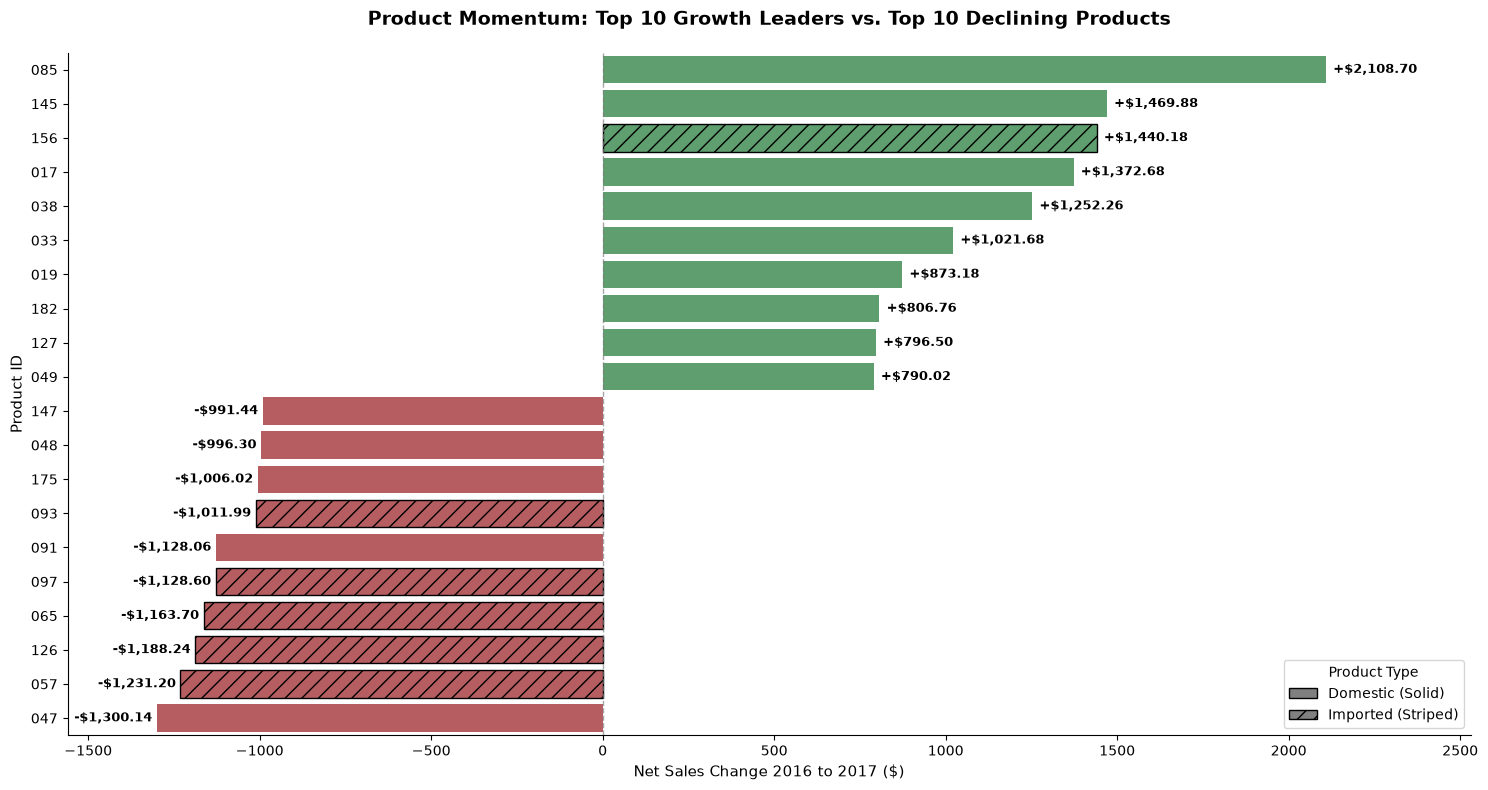

In [26]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# 1. Sort to grab the top 10 and bottom 10 growth products
sorted_growth = df_yoy.sort_values(by="Sales_Growth")
extremes = pd.concat([sorted_growth.head(10), sorted_growth.tail(10)])
extremes = extremes.reset_index()

# Sort so the chart reads cleanly from top to bottom (biggest winner to biggest loser)
extremes = extremes.sort_values("Sales_Growth", ascending=False)

# 2. Create a clean color mapping dictionary tied directly to the Product_ID
color_map = {
    row["Product_ID"]: "#55a868" if row["Sales_Growth"] > 0 else "#c44e52"
    for _, row in extremes.iterrows()
}

# 3. Plotting
fig, ax = plt.subplots(figsize=(15, 8))

sns.barplot(
    data=extremes,
    x="Sales_Growth",
    y="Product_ID",
    hue="Product_ID",
    palette=color_map,
    legend=False,
    ax=ax,
)

# 4. Loop through the bars to apply the hatch pattern for Imported products
# ax.patches contains the bars in the order they are drawn on the screen
for patch, (_, row) in zip(ax.patches, extremes.iterrows()):
    if row["Import"] == 1:
        patch.set_hatch("//")  # Apply diagonal stripes
        patch.set_edgecolor("black")  # Ensure the pattern stands out clearly
        patch.set_linewidth(1)

# 5. Add exact value labels onto the end of each bar for standalone clarity
for p in ax.patches:
    width = p.get_width()
    if width >= 0:
        ha_align = "left"
        padding = width + (extremes["Sales_Growth"].max() * 0.01)
        label_text = f"+${width:,.2f}"
    else:
        ha_align = "right"
        padding = width - (abs(extremes["Sales_Growth"].min()) * 0.01)
        label_text = f"-${abs(width):,.2f}"

    ax.text(
        padding,
        p.get_y() + p.get_height() / 2,
        label_text,
        va="center",
        ha=ha_align,
        fontsize=9,
        fontweight="bold",
    )

# 6. Final Polish, Titles, and a Custom Legend for the Patterns
plt.title(
    "Product Momentum: Top 10 Growth Leaders vs. Top 10 Declining Products",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Net Sales Change 2016 to 2017 ($)", fontsize=11)
plt.ylabel("Product ID", fontsize=11)

# Add a vertical anchor line at $0
plt.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# Give the text labels some breathing room on the sides
plt.xlim(
    extremes["Sales_Growth"].min() * 1.2,
    extremes["Sales_Growth"].max() * 1.2,
)

# Create a manual legend to explain the solid vs pattern bars
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Domestic (Solid)"),
    Patch(
        facecolor="gray",
        hatch="//",
        edgecolor="black",
        label="Imported (Striped)",
    ),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    title="Product Type",
)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

In [27]:
# Question 4

# 4a Setup

# Loading data into df

xl_path = os.path.join(curdir, 'Data', '860_Assignment1_Data_vf.xlsx')

collinear = pd.read_excel(
    xl_path, 
    sheet_name='Collinearity',
    index_col='Obs'
)

# See what data looks like
collinear.head()

,Y,Experience,Height,Weight
Obs,,,,
1,450,3,52,58
2,330,3,33,36
3,505,5,37,52
4,254,3,44,52
5,186,2,14,27


In [28]:
# Create new df with top 25
col_top25 = collinear[:25]

# Review the data
col_top25.describe()

,Y,Experience,Height,Weight
count,25.000000,25.000000,25.000000,25.000000
mean,336.360000,3.000000,42.280000,47.040000
std,179.682563,1.354006,29.299488,21.597608
min,8.000000,1.000000,3.000000,13.000000
25%,182.000000,2.000000,14.000000,31.000000
50%,386.000000,3.000000,37.000000,39.000000
75%,484.000000,4.000000,65.000000,60.000000
max,593.000000,5.000000,96.000000,90.000000


In [29]:
def get_model_interpretation(model, model_name, variables):
    """
    Prints a balanced statistical and practical interpretation of a statsmodels OLS result.
    """
    print(f"--- Interpretation for {model_name} ---")
    
    # 1. Evaluate the F-Statistic
    f_stat = round(model.fvalue, 2)
    f_pvalue = model.f_pvalue
    
    print(f"F-Statistic Evaluation:")
    if f_pvalue > 0.05:
        print(f"  • The F-statistic is {f_stat} with a p-value of {round(f_pvalue, 4)} (> 0.05).")
        print("  • Conclusion: This model is statistically insignificant. The variables are just predicting random noise, so the test is pointless.")
        return
    else:
        print(f"  • The F-statistic is {f_stat} with a highly significant p-value of {f_pvalue:.4e} (< 0.05).")
        print("  • Conclusion: The overall model is valid and statistically significant. We should proceed to the individual variables.")
    
    print("\nT-Statistic & Variable Evaluation:")
    insignificant_drivers = []
    significant_drivers = []
    
    # 2. Evaluate individual T-statistics and p-values
    for var in variables:
        if var in model.pvalues:
            t_stat = round(model.tvalues[var], 2)
            p_val = model.pvalues[var]
            
            if p_val > 0.05:
                insignificant_drivers.append(var)
                print(f"  • {var}: t-stat is close to 0 ({t_stat}), p-value is {round(p_val, 4)} (> 0.05).")
                print(f"    Meaning: {var} has no statistical impact here; its effect cannot be explained by this model.")
            else:
                significant_drivers.append(var)
                print(f"  • {var}: t-stat is strong ({t_stat}), p-value is {round(p_val, 4)} (< 0.05).")
                print(f"    Meaning: {var} is a mathematically valid, reliable driver of the outcome.")
                
    # 3. Collinearity Check / Takeaway
    if len(insignificant_drivers) > 0 and 'Height' in variables and 'Weight' in variables:
        print("\nCollinearity Warning:")
        print("  • When analyzed together, individual t-stats drop toward 0 because Height and Weight move together.")
        print("  • They carry overlapping information, causing them to steal variance from one another in the model.")
    
    # 4. Evaluate R-squared
    r2 = round(model.rsquared, 4)
    print(f"\nExplanatory Power (R-squared):")
    print(f"  • The R-squared value is {r2}.")
    print(f"  • Meaning: Closer to 1 is better. This model successfully explains {round(r2 * 100, 2)}% of the total variance in Y.")
    print("-" * 50 + "\n")

In [30]:
# 4i 
# First 25 observations: Y explained by Experience and Height
model_25_height = smf.ols('Y ~ Experience + Height', data=col_top25).fit()

print('Model 1 - 25 obs: Y ~ Experience + Height')
print(model_25_height.summary())
print(f"\nF-stat: A value of 79.49 with an extremely small p-value indicates the model is highly significant.\nT-stat: Both parameters have non-zero t-statistics with very low p-values, confirming strong individual significance.\nR-squared: The model explains 87.8% of the variation in Y, indicating excellent fit.\nHeight does appear to explain Y. The coefficient on Height is positive, statistically significant at the 1% level, and materially meaningful.\nHolding Experience constant, each additional unit of Height increases Y by approximately 1.67 units.")


Model 1 - 25 obs: Y ~ Experience + Height
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     79.49
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           8.56e-11
Time:                        18:05:55   Log-Likelihood:                -138.40
No. Observations:                  25   AIC:                             282.8
Df Residuals:                      22   BIC:                             286.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept 

In [31]:
# 4ii 
# First 25 observations: Y explained by Experience and Weight
model_25_weight = smf.ols('Y ~ Experience + Weight', data=col_top25).fit()

print('Model 2 - 25 obs: Y ~ Experience + Weight')
print(model_25_weight.summary())
print(f"\nF-stat: A value of 65.01 with an extremely small p-value indicates the model is statistically significant, though slightly weaker than the Height model.\nT-stat: Both parameters have non-zero t-statistics with low p-values, confirming individual significance.\nR-squared: The model explains 85.5% of the variation in Y, which is strong but lower than the Height model.\nWeight does appear to explain Y, but it is a weaker predictor than Height. The coefficient on Weight is positive and statistically significant at the 5% level, indicating a modest effect.\nHolding Experience constant, each additional unit of Weight increases Y by approximately 1.60 units. The model relies more heavily on Experience when Weight is included.")


Model 2 - 25 obs: Y ~ Experience + Weight
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     65.01
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           5.83e-10
Time:                        18:05:55   Log-Likelihood:                -140.58
No. Observations:                  25   AIC:                             287.2
Df Residuals:                      22   BIC:                             290.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept 

In [32]:
# 4iii 
# First 25 observations: Y explained by Experience, Height, and Weight
model_25_both = smf.ols('Y ~ Experience + Height + Weight', data=col_top25).fit()

print('Model 3 - 25 obs: Y ~ Experience + Height + Weight')
print(model_25_both.summary())
print(f"\nF-stat: A value of 51.17 with an extremely small p-value indicates the model is statistically significant overall, though weaker than the two-variable models.\nT-stat: Experience remains highly significant, but Height becomes only marginally significant and Weight becomes fully insignificant.\nR-squared: The model explains 88.0% of the variation in Y, similar to the Height-only model and indicating that Weight adds little additional explanatory value.\nHeight and Weight do not both explain Y when included together. Height is barely significant (p = 0.052) and Weight is not significant (p = 0.649).\nThis pattern is consistent with collinearity. Height and Weight contain overlapping information, so when both are included, neither contributes strong unique explanatory power.\nExperience continues to carry most of the explanatory strength in the model.")


Model 3 - 25 obs: Y ~ Experience + Height + Weight
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     51.17
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           7.89e-10
Time:                        18:05:55   Log-Likelihood:                -138.27
No. Observations:                  25   AIC:                             284.5
Df Residuals:                      21   BIC:                             289.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
I

In [33]:
# 4iv
# All 100 observations: Y explained by Experience and Height
model_100_height = smf.ols('Y ~ Experience + Height', data=collinear).fit()

print('Model 4 - 100 obs: Y ~ Experience + Height')
print(model_100_height.summary())
print(f"\nF-stat: A value of 255.0 with an extremely small p-value indicates the model is highly significant, and even stronger than the 25-observation version.\nT-stat: Both parameters have very large t-statistics with extremely low p-values, confirming strong individual significance.\nR-squared: The model explains 84.0% of the variation in Y, slightly lower than the 25-observation model but still indicating excellent fit.\nHeight continues to explain Y. The coefficient on Height is positive and statistically significant at well below the 1% level (t = 6.94).\nWith more observations, the estimate becomes more precise. Height’s standard error decreases and its significance strengthens.\nHolding Experience constant, each additional unit of Height increases Y by approximately 1.28 units, which is consistent with the earlier model but estimated more reliably with 100 observations.")

Model 4 - 100 obs: Y ~ Experience + Height
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     255.0
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           2.36e-39
Time:                        18:05:55   Log-Likelihood:                -540.07
No. Observations:                 100   AIC:                             1086.
Df Residuals:                      97   BIC:                             1094.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept

In [34]:
# 4v
# All 100 observations: Y explained by Experience and Weight
model_100_weight = smf.ols('Y ~ Experience + Weight', data=collinear).fit()

print('Model 5 - 100 obs: Y ~ Experience + Weight')
print(model_100_weight.summary())
print(f"\nF-stat: A value of 217.0 with an extremely small p-value indicates the model is highly significant, though slightly weaker than the Height model with 100 observations.\nT-stat: Both parameters have very large t-statistics with extremely low p-values, confirming strong individual significance.\nR-squared: The model explains 81.7% of the variation in Y, which is strong but lower than the Height model.\nWeight continues to explain Y. The coefficient on Weight is positive and statistically significant at well below the 1% level (t = 5.47).\nWith more observations, the estimate becomes much more precise. Weight’s standard error decreases and its significance strengthens compared to the 25-observation model.\nHolding Experience constant, each additional unit of Weight increases Y by approximately 1.55 units, consistent with the earlier model but estimated more reliably with 100 observations.")


Model 5 - 100 obs: Y ~ Experience + Weight
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     217.0
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.55e-36
Time:                        18:05:55   Log-Likelihood:                -546.75
No. Observations:                 100   AIC:                             1100.
Df Residuals:                      97   BIC:                             1107.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept

In [35]:
# 4vi
# All 100 observations: Y explained by Experience, Height, and Weight
model_100_both = smf.ols('Y ~ Experience + Height + Weight', data=collinear).fit()

print('Model 6 - 100 obs: Y ~ Experience + Height + Weight')
print(model_100_both.summary())
print(f"\nF-stat: A value of 168.3 with an extremely small p-value indicates the model is statistically significant overall, though weaker than the two-variable models with 100 observations.\nT-stat: Experience remains highly significant, Height is strongly significant, but Weight becomes fully insignificant.\nR-squared: The model explains 84.0% of the variation in Y, identical to the Height-only model and indicating that Weight adds no additional explanatory value.\nHeight and Weight do not both explain Y when included together. Height remains significant (t = 3.71), but Weight is not significant at all (p = 0.945).\nThis pattern is consistent with collinearity. Height and Weight contain overlapping information, so when both are included, Weight contributes no unique explanatory power.\nExperience continues to carry most of the explanatory strength in the model, with Height providing additional support and Weight offering none.")

Model 6 - 100 obs: Y ~ Experience + Height + Weight
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     168.3
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           4.27e-38
Time:                        18:05:55   Log-Likelihood:                -540.07
No. Observations:                 100   AIC:                             1088.
Df Residuals:                      96   BIC:                             1099.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


In [36]:
# Question 4b

'''
The key observation across models is that Height and Weight look significant when used individually 
but their value (t-stat) weakens when they are used together. This happens because Height and Weight 
are collinear, making it difficult for the model to separate their individual effects. As a result, 
Weight becomes insignificant and Height becomes less precise, even though the overall model fit stays 
strong.

The lesson here is we should avoid using multiple variables that measure the same underlying trait, 
or choose the one that is most interpretable or most predictive, like Height was in our example.
'''

'\nThe key observation across models is that Height and Weight look significant when used individually \nbut their value (t-stat) weakens when they are used together. This happens because Height and Weight \nare collinear, making it difficult for the model to separate their individual effects. As a result, \nWeight becomes insignificant and Height becomes less precise, even though the overall model fit stays \nstrong.\n\nThe lesson here is we should avoid using multiple variables that measure the same underlying trait, \nor choose the one that is most interpretable or most predictive, like Height was in our example.\n'